In [ ]:
import pandas as pd
import numpy as np
import re

In [ ]:
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv("/content/gurgaon_cleaned_properties.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   society          1563 non-null   object 
 1   price            1563 non-null   float64
 2   area             1563 non-null   int64  
 3   areaWithType     1563 non-null   object 
 4   bedRoom          1563 non-null   int64  
 5   bathroom         1563 non-null   int64  
 6   balcony          1563 non-null   object 
 7   additionalRoom   1563 non-null   object 
 8   floorNum         1563 non-null   object 
 9   facing           1563 non-null   object 
 10  agePossession    1562 non-null   object 
 11  nearbyLocations  1563 non-null   object 
 12  furnishDetails   1563 non-null   object 
 13  features         1563 non-null   object 
 14  latitude         1563 non-null   float64
 15  longitude        1563 non-null   float64
 16  price_per_sqft   1563 non-null   float64
 17  sector        

In [ ]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features

,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,latitude,longitude,price_per_sqft,sector
0,dlf the magnolias,45.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up area: 6000 sqft (557.42 sq.m.)Carpet area: 5400 sqft (501.68 sq.m.) sqft,4,4,3+,"pooja room,study room,servant room,others",14,North-East,5 to 10 Year Old,"['Ambience Public School', 'Heritage Intl Xperiential School', 'Summer Fields School', 'Primamed Super Speciality Hospital', 'Uma Sanjeevani Health Centre', 'Anya Gurgaon', 'Hotel Golf View Suites', 'Apollo Pharmacy', 'Rx Pharmacy', 'Sector 42/43 Bus Stand', 'Genpact Chowk Bus Stop', 'Huda City Centre Metro Station', 'Sector 53 Metro Station', 'ICICI Bank ATM', 'Bharat Petroleum Retail Outlet']","['1 Water Purifier', 'Fan', '1 Fridge', '1 Exhaust Fan', '5 Geyser', '1 Stove', 'Light', '8 AC', '1 Modular Kitchen', '1 Chimney', '5 Wardrobe', '1 Washing Machine', '1 Microwave', 'No Bed', 'No Dining Table', 'No Sofa', 'No TV']",['Vaastu Compliant'],28.454042,77.09874,70312.0,Sector 42


In [ ]:
df.duplicated().sum()

np.int64(0)

# 1. areaWithType

In [ ]:
df['areaWithType'].head()

,areaWithType
0,Super Built-up area 6400(594.58 sq.m.)Built-up area: 6000 sqft (557.42 sq.m.)Carpet area: 5400 sqft (501.68 sq.m.) sqft
1,Super Built-up area 1855(172.34 sq.m.) sqft
2,Super Built-up area 3763(349.59 sq.m.)Built-up area: 2873.18 sqft (266.93 sq.m.) sqft
3,Super Built-up area 2125(197.42 sq.m.)Carpet area: 1141 sqft (106 sq.m.) sqft
4,Super Built-up area 2727(253.35 sq.m.)Built-up area: 2725 sqft (253.16 sq.m.)Carpet area: 2721 sqft (252.79 sq.m.) sqft


In [ ]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
950,2.05,1929,Super Built-up area 1929(179.21 sq.m.) sqft
728,2.65,2000,Super Built-up area 2000(185.81 sq.m.)Built-up area: 1638 sqft (152.18 sq.m.)Carpet area: 1500 sqft (139.35 sq.m.) sqft
834,4.95,2864,Super Built-up area 2864(266.07 sq.m.)Built-up area: 2564 sqft (238.2 sq.m.)Carpet area: 2100 sqft (195.1 sq.m.) sqft
1104,3.10,2631,Super Built-up area 2631(244.43 sq.m.)Built-up area: 2088.21 sqft (194 sq.m.)Carpet area: 1598.78 sqft (148.53 sq.m.) sqft
336,1.01,865,Super Built-up area 865(80.36 sq.m.)Carpet area: 700 sqft (65.03 sq.m.) sqft


In [ ]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    pattern = r'Super\s*Built[- ]up\s*area\s*(\d+\.?\d*)'
    match = re.search(pattern, text, re.IGNORECASE)

    if match:
        return float(match.group(1))
    return None

In [ ]:
import re

def extract_areas(text):
    if not isinstance(text, str):
        return None, None, None

    text = text.replace('–', '-').replace('—', '-')

    super_area = re.search(r'Super\s*Built[- ]up\s*area\s*([\d]+(?:\.\d+)?)', text, re.I)
    built_area = re.search(
    r'(?<!Super\s)Built[- ]up\s*area\s*:?\s*([\d]+(?:\.\d+)?)',
    text,
    re.I
)
    carpet_area = re.search(r'Carpet\s*area\s*:?\s*([\d]+(?:\.\d+)?)', text, re.I)

    return (
        float(super_area.group(1)) if super_area else None,
        float(built_area.group(1)) if built_area else None,
        float(carpet_area.group(1)) if carpet_area else None
    )

In [ ]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [ ]:
df[['super_built_up_area','built_up_area','carpet_area']] = df['areaWithType'].apply(
    lambda x: pd.Series(extract_areas(x))
)

In [ ]:
# Extract Super Built up area and convert to sqft if needed
#df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [ ]:
df[['price','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1542,1.70,1620,Super Built-up area 1620(150.5 sq.m.) sqft,1620.0,NaN,NaN
341,13.10,3979,Super Built-up area 3979(369.66 sq.m.)Carpet area: 3500 sqft (325.16 sq.m.) sqft,3979.0,NaN,3500.0
840,5.25,2343,Built-up area: 2343 (217.67 sq.m.) sqft,NaN,2343.0,NaN
1348,2.20,1850,Super Built-up area 1850(171.87 sq.m.) sqft,1850.0,NaN,NaN
586,3.90,1950,Super Built-up area 1950(181.16 sq.m.)Built-up area: 1920 sqft (178.37 sq.m.)Carpet area: 1550 sqft (144 sq.m.) sqft,1950.0,1920.0,1550.0


In [ ]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1172,4.95,2905,Super Built-up area 2905(269.88 sq.m.)Built-up area: 2700 sqft (250.84 sq.m.)Carpet area: 2500 sqft (232.26 sq.m.) sqft,2905.0,2700.0,2500.0
1246,4.50,2925,Super Built-up area 2925(271.74 sq.m.)Built-up area: 2499.8 sqft (232.24 sq.m.)Carpet area: 2152 sqft (199.93 sq.m.) sqft,2925.0,2499.8,2152.0
930,4.65,2625,Super Built-up area 2625(243.87 sq.m.)Built-up area: 2200 sqft (204.39 sq.m.)Carpet area: 1963 sqft (182.37 sq.m.) sqft,2625.0,2200.0,1963.0
983,3.60,2175,Super Built-up area 2175(202.06 sq.m.)Built-up area: 1743 sqft (161.93 sq.m.)Carpet area: 1211 sqft (112.51 sq.m.) sqft,2175.0,1743.0,1211.0
1047,4.85,2527,Super Built-up area 2527(234.77 sq.m.)Built-up area: 2427 sqft (225.48 sq.m.)Carpet area: 2050 sqft (190.45 sq.m.) sqft,2527.0,2427.0,2050.0


In [ ]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(409, 6)

In [ ]:
df.isnull().sum()

,0
society,0
price,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0
additionalRoom,0
floorNum,0
facing,0


In [ ]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [ ]:
all_nan_df.head()

,price,area,areaWithType,super_built_up_area,built_up_area,carpet_area


In [ ]:
df.head(1)

,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,latitude,longitude,price_per_sqft,sector,super_built_up_area,built_up_area,carpet_area
0,dlf the magnolias,45.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up area: 6000 sqft (557.42 sq.m.)Carpet area: 5400 sqft (501.68 sq.m.) sqft,4,4,3+,"pooja room,study room,servant room,others",14,North-East,5 to 10 Year Old,"['Ambience Public School', 'Heritage Intl Xperiential School', 'Summer Fields School', 'Primamed Super Speciality Hospital', 'Uma Sanjeevani Health Centre', 'Anya Gurgaon', 'Hotel Golf View Suites', 'Apollo Pharmacy', 'Rx Pharmacy', 'Sector 42/43 Bus Stand', 'Genpact Chowk Bus Stop', 'Huda City Centre Metro Station', 'Sector 53 Metro Station', 'ICICI Bank ATM', 'Bharat Petroleum Retail Outlet']","['1 Water Purifier', 'Fan', '1 Fridge', '1 Exhaust Fan', '5 Geyser', '1 Stove', 'Light', '8 AC', '1 Modular Kitchen', '1 Chimney', '5 Wardrobe', '1 Washing Machine', '1 Microwave', 'No Bed', 'No Dining Table', 'No Sofa', 'No TV']",['Vaastu Compliant'],28.454042,77.09874,70312.0,Sector 42,6400.0,6000.0,5400.0


# 2. additionalRoom

In [ ]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
servant room,641
study room,155
pooja room,115
others,107
"pooja room,servant room",83
"study room,servant room",66
store room,62
"pooja room,study room,servant room,store room",43
"servant room,pooja room",34


In [ ]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [ ]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1275,servant room,0,1,0,0,0
910,servant room,0,1,0,0,0
464,"study room,store room",1,0,1,0,0
24,"pooja room,servant room",0,1,0,1,0
971,servant room,0,1,0,0,0


# 3.agePossesion

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,688
0 to 1 Year Old,374
5 to 10 Year Old,339
10+ Year Old,106
Dec 2028,6
undefined,4
Dec 2030,3
Mar 2029,3
Within 3 months,3


In [ ]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [ ]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,688
New Property,378
Moderately Old,339
Old Property,106
Under Construction,47
Undefined,5


# 4.furnishDetails

In [ ]:
df = df.applymap(lambda x: np.nan if x == [] or x == '[]' else x)

/tmp/ipykernel_2608/3865984614.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: np.nan if x == [] or x == '[]' else x)


In [ ]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1051,NaN,NaN
274,"['2 Wardrobe', 'Fan', '3 Geyser', '1 Stove', 'Light', '1 Modular Kitchen', '1 Chimney', '3 AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Power Back-up', 'Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Piped-gas', 'Recently Renovated']"
877,NaN,"['Corner Property', 'Power Back-up', 'Vaastu Compliant', 'High Ceiling Height', 'Piped-gas']"
779,"['4 Wardrobe', 'Fan', '1 Exhaust Fan', '5 Geyser', 'Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",['Vaastu Compliant']
479,"['2 Wardrobe', 'Fan', 'Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",NaN


In [ ]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2608/2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [ ]:
furnishings_df.sample(5)

,furnishDetails,Sofa,Bed,Chimney,Exhaust Fan,Microwave,Light,Fan,Geyser,AC,Wardrobe,Modular Kitchen,Water Purifier,Washing Machine,TV,Dining Table,Fridge,Stove,Curtains
895,"['3 Wardrobe', '1 Exhaust Fan', 'Light', '1 Modular Kitchen', '3 AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0,0,0,1,0,1,0,0,3,3,1,0,0,0,0,0,0,0
921,"['2 Wardrobe', 'Fan', '1 Exhaust Fan', '1 Geyser', 'Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0,0,0,1,0,1,1,1,0,2,1,0,0,0,0,0,0,0
117,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1121,"['1 Water Purifier', 'Fan', '1 Fridge', '1 Exhaust Fan', '4 Geyser', 'Light', '6 AC', '1 Modular Kitchen', '1 Chimney', '4 Wardrobe', '1 Microwave', 'No Bed', 'No Dining Table', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']",0,0,1,1,1,1,1,4,6,4,1,1,0,0,0,1,0,0
560,"['4 Wardrobe', '3 Geyser', '1 Modular Kitchen', '5 AC', '1 Chimney', 'No Bed', 'No Dining Table', 'No Fan', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0,0,1,0,0,0,0,3,5,4,1,0,0,0,0,0,0,0


In [ ]:
furnishings_df.shape

(1563, 19)

In [ ]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_2608/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [ ]:
furnishings_df.sample(5)

,Sofa,Bed,Chimney,Exhaust Fan,Microwave,Light,Fan,Geyser,AC,Wardrobe,Modular Kitchen,Water Purifier,Washing Machine,TV,Dining Table,Fridge,Stove,Curtains
917,0,4,1,0,0,0,0,2,3,3,1,0,0,1,0,0,0,0
543,0,0,0,0,0,1,0,2,4,2,1,0,0,0,0,0,0,0
1239,0,0,1,0,0,1,1,4,4,3,1,0,0,0,0,0,1,0
578,0,0,1,1,0,1,1,3,5,3,1,0,0,0,0,0,0,0
1323,0,0,1,0,1,1,1,4,4,3,1,1,0,0,1,1,1,1


In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------
# 1. Missing handling
# -------------------------------
df['furnishing_missing'] = df['furnishDetails'].isna().astype(int)
df['furnishDetails'] = df['furnishDetails'].fillna("")

# -------------------------------
# 2. Extract unique furnishings
# -------------------------------
all_furnishings = []

for detail in df['furnishDetails']:
    items = detail.replace('[','').replace(']','').replace("'","").split(', ')
    all_furnishings.extend(items)

unique_furnishings = list(set(all_furnishings))

# clean names
columns_to_include = [re.sub(r'No |\d+', '', f).strip() for f in unique_furnishings]
columns_to_include = list(set([f for f in columns_to_include if f]))

# -------------------------------
# 3. Count extraction function (FIXED REGEX)
# -------------------------------
def get_furnishing_count(details, furnishing):
    if isinstance(details, str) and details != "":

        # explicit No case
        if f"No {furnishing}" in details:
            return 0

        # FIXED regex
        pattern = re.compile(rf"(\d+)\s+{re.escape(furnishing)}")
        match = pattern.search(details)

        if match:
            return int(match.group(1))

        # present without number
        elif furnishing in details:
            return 1

    return 0

# -------------------------------
# 4. Create furnishing columns
# -------------------------------
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(
        lambda x: get_furnishing_count(x, furnishing)
    )

furnishing_cols = columns_to_include

# -------------------------------
# 5. Furnishing score
# -------------------------------
df['furnishing_score'] = df[furnishing_cols].sum(axis=1)

# -------------------------------
# 6. Scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[furnishing_cols])

# -------------------------------
# 7. Find best K
# -------------------------------
best_k = 2
best_score = -1

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)

# -------------------------------
# 8. Final clustering
# -------------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['furnishing_cluster'] = kmeans.fit_predict(X_scaled)

# -------------------------------
# 9. Cluster → label mapping
# -------------------------------
cluster_mean = df.groupby('furnishing_cluster')['furnishing_score'].mean().sort_values()
cluster_ids = list(cluster_mean.index)

mapping = {}

if len(cluster_ids) == 2:
    mapping[cluster_ids[0]] = 'Semi-Furnished'
    mapping[cluster_ids[1]] = 'Furnished'
else:
    labels = ['Unfurnished', 'Semi-Furnished', 'Furnished']
    for i, cid in enumerate(cluster_ids):
        mapping[cid] = labels[i] if i < 3 else 'Furnished'

# initial assignment
df['furnishing_type'] = df['furnishing_cluster'].map(mapping)

# -------------------------------
# 10. FINAL RULE FIX (CRITICAL)
# -------------------------------

# UNKNOWN → missing data
df.loc[df['furnishDetails'] == "", 'furnishing_type'] = 'Unknown'

# TRUE UNFURNISHED → all "No" but data present
df.loc[
    (df['furnishing_score'] == 0) & (df['furnishDetails'] != ""),
    'furnishing_type'
] = 'Unfurnished'

# -------------------------------
# 12. Checks
# -------------------------------
print("\nFinal Distribution:\n", df['furnishing_type'].value_counts())

print("\nSanity Check:\n")
print(df.groupby('furnishing_type')[furnishing_cols].mean())

K=2, Score=0.4834
K=3, Score=0.3247
K=4, Score=0.3348
K=5, Score=0.3139
Best K: 2

Final Distribution:
 furnishing_type
Semi-Furnished    1065
Unknown            337
Furnished          161
Name: count, dtype: int64

Sanity Check:

                     Sofa       Bed   Chimney  Exhaust Fan  Microwave  \
furnishing_type                                                         
Furnished        0.472050  1.248447  0.968944     0.515528   0.919255   
Semi-Furnished   0.011268  0.030047  0.722066     0.338028   0.084507   
Unknown          0.000000  0.000000  0.000000     0.000000   0.000000   

                    Light       Fan    Geyser        AC  Wardrobe  \
furnishing_type                                                     
Furnished        0.956522  0.956522  3.559006  5.142857  4.229814   
Semi-Furnished   0.812207  0.767136  2.098592  3.337089  2.299531   
Unknown          0.000000  0.000000  0.000000  0.000000  0.000000   

                 Modular Kitchen  Water Purifier  Washing

In [ ]:
df[
    (df['furnishing_score'] == 0) &
    (df['furnishDetails'] != "")
].shape

(0, 48)

In [ ]:
df.groupby('furnishing_type')['furnishing_score'].describe()

,count,mean,std,min,25%,50%,75%,max
furnishing_type,,,,,,,,
Furnished,161.0,25.180124,8.015523,9.0,20.0,24.0,28.0,58.0
Semi-Furnished,1065.0,12.024413,5.586248,1.0,8.0,12.0,16.0,30.0
Unknown,337.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.sample(10)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
395,"['4 Wardrobe', 'Fan', '3 Geyser', 'Light', '1 Chimney', '1 Modular Kitchen', '4 AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",Semi-Furnished
404,"['1 Water Purifier', '1 Fridge', 'Fan', '1 Dining Table', '3 Geyser', '1 Stove', 'Light', '1 Modular Kitchen', '4 AC', '3 TV', '1 Chimney', '3 Wardrobe', '3 Bed', '1 Sofa', '1 Washing Machine', '1 Microwave']",Furnished
183,"['1 Water Purifier', 'Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '5 Geyser', '1 Stove', 'Light', '6 AC', '5 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 Bed', '4 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave']",Furnished
1070,"['1 Water Purifier', 'Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', 'Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 AC', '3 Wardrobe', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']",Semi-Furnished
1168,,Unknown
795,,Unknown
1099,"['4 Wardrobe', 'Fan', '1 Sofa', '4 Geyser', 'Light', '1 Modular Kitchen', '6 AC', '1 Chimney', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",Semi-Furnished
809,"['Fan', 'Light', '5 AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",Semi-Furnished
585,"['2 Wardrobe', 'Fan', '1 Exhaust Fan', '3 Geyser', 'Light', '1 Modular Kitchen', '3 AC', '1 Chimney', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",Semi-Furnished
561,,Unknown


In [ ]:
df.groupby('furnishing_cluster')['furnishing_score'].mean()

,furnishing_score
furnishing_cluster,
0,9.134094
1,25.180124


In [ ]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
Semi-Furnished,1065
Unknown,337
Furnished,161


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   society              1563 non-null   object 
 1   price                1563 non-null   float64
 2   area                 1563 non-null   int64  
 3   areaWithType         1563 non-null   object 
 4   bedRoom              1563 non-null   int64  
 5   bathroom             1563 non-null   int64  
 6   balcony              1563 non-null   object 
 7   additionalRoom       1563 non-null   object 
 8   floorNum             1563 non-null   object 
 9   facing               1563 non-null   object 
 10  agePossession        1563 non-null   object 
 11  nearbyLocations      1560 non-null   object 
 12  furnishDetails       1563 non-null   object 
 13  features             1000 non-null   object 
 14  latitude             1563 non-null   float64
 15  longitude            1563 non-null   f

# 5.features

In [ ]:
df['features'].sample(10)

,features
1108,"['Vaastu Compliant', 'Centrally Air Conditioned', 'High Ceiling Height']"
933,NaN
691,NaN
1259,NaN
127,NaN
588,"['Centrally Air Conditioned', 'Power Back-up', 'Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Piped-gas', 'Recently Renovated']"
643,NaN
112,"['Corner Property', 'Power Back-up', 'Vaastu Compliant', 'Recently Renovated', 'Piped-gas']"
881,"['Private Garden / Terrace', 'Separate entry for servant room', 'Piped-gas']"
1315,NaN


In [ ]:
df['features'].isnull().sum()

np.int64(563)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [ ]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [ ]:
features_binary_df.head(5)

,Bank Attached Property,Centrally Air Conditioned,Club house,Corner Property,False Ceiling Lighting,Fitness Centre / GYM,High Ceiling Height,Intercom Facility,Lift(s),Low Density Society,Maintenance Staff,Park,Piped-gas,Power Back-up,Private Garden,Private Garden / Terrace,Rain Water Harvesting,Recently Renovated,Security / Fire Alarm,Security Guard,Separate entry for servant room,Shopping Centre,Swimming Pool,Vaastu Compliant,Visitor Parking,Water Storage
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0


In [ ]:
features_binary_df.shape

(1563, 26)

In [ ]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

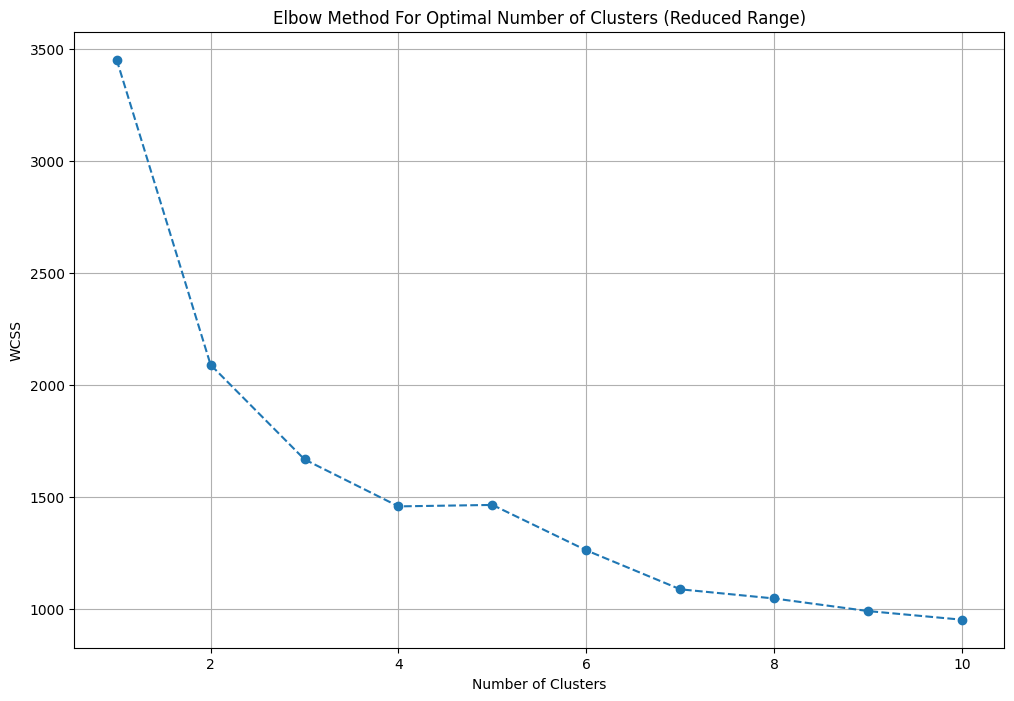

In [ ]:
# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
weights = {
    # 🔥 Core luxury (high impact)
    'Swimming Pool': 5,
    'Private Garden': 5,
    'Private Garden / Terrace': 5,
    'Club house': 4,
    'Fitness Centre / GYM': 4,

    # ⭐ Strong lifestyle indicators
    'Low Density Society': 4,
    'Centrally Air Conditioned': 4,

    # ⭐ Medium (common but valuable)
    'Power Back-up': 2,
    'Lift(s)': 2,
    'Security Guard': 2,
    'Security / Fire Alarm': 2,
    'Visitor Parking': 2,
    'Piped-gas': 2,

    # 🏠 Supporting features
    'Maintenance Staff': 1,
    'Intercom Facility': 1,
    'Vaastu Compliant': 1,
    'Park': 1,

    # 🧠 Design / niche
    'High Ceiling Height': 2,
    'False Ceiling Lighting': 1,
    'Corner Property': 1,

    # 🚫 ignore / noise
    'Bank Attached Property': 0
}

import numpy as np

# =========================
# STEP 1: Ensure all feature columns exist
# =========================

for col in weights.keys():
    if col not in features_binary_df.columns:
        features_binary_df[col] = 0


# =========================
# STEP 2: Raw weighted score
# =========================

raw_score = features_binary_df[list(weights.keys())] \
    .multiply(list(weights.values())) \
    .sum(axis=1)

max_score = sum(weights.values())

feature_score = raw_score / max_score   # normalize (0–1)


# =========================
# STEP 3: Detect missing feature rows
# =========================

missing_mask = (features_binary_df.sum(axis=1) == 0)


# =========================
# STEP 4: Price signal
# =========================

price_signal = df['price_per_sqft'] / df['price_per_sqft'].max()


# =========================
# STEP 5: Area signal
# =========================

area_signal = df['area'] / df['area'].max()


# =========================
# STEP 6: Combine (NO furnishing)
# =========================

df['luxury_score'] = (
    0.6 * feature_score +
    0.3 * price_signal +
    0.1 * area_signal
)


# =========================
# STEP 7: Fix missing feature rows
# =========================

df.loc[missing_mask, 'luxury_score'] = (
    0.7 * price_signal[missing_mask] +
    0.3 * area_signal[missing_mask]
)


# =========================
# STEP 8: Final scale
# =========================

df['luxury_score'] = df['luxury_score'].clip(0, 1)
df['luxury_score'] = (df['luxury_score'] * 100).round()

In [ ]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [ ]:
df[df['luxury_score'] > 40]['price']

,price
26,24.00
459,2.65
1029,1.60
1130,3.30
1175,2.40


In [ ]:
df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,dlf the magnolias,Sector 42,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up area: 6000 sqft (557.42 sq.m.)Carpet area: 5400 sqft (501.68 sq.m.) sqft,4,4,3+,14,North-East,Moderately Old,6400.0,6000.00,5400.0,1,1,0,1,1,Furnished,11.29,28.454042,77.098740
1,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8,East,Relatively New,1855.0,NaN,NaN,1,1,0,1,1,Unknown,6.15,28.508181,76.986806
2,experion windchants,Sector 112,6.25,16609.0,3763,Super Built-up area 3763(349.59 sq.m.)Built-up area: 2873.18 sqft (266.93 sq.m.) sqft,3,5,3,6,North,Moderately Old,3763.0,2873.18,NaN,0,1,0,0,0,Semi-Furnished,12.50,28.518719,77.014458
3,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet area: 1141 sqft (106 sq.m.) sqft,3,3,3,11,North,Under Construction,2125.0,NaN,1141.0,0,1,0,0,0,Unknown,8.09,28.359337,76.969227
4,dlf new town heights 1,Sector 90,2.85,10451.0,2727,Super Built-up area 2727(253.35 sq.m.)Built-up area: 2725 sqft (253.16 sq.m.)Carpet area: 2721 sqft (252.79 sq.m.) sqft,4,4,3+,4,North-West,Moderately Old,2727.0,2725.00,2721.0,0,1,0,1,0,Semi-Furnished,20.74,28.403442,76.930775


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 50 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   society              1563 non-null   object 
 1   price                1563 non-null   float64
 2   area                 1563 non-null   int64  
 3   areaWithType         1563 non-null   object 
 4   bedRoom              1563 non-null   int64  
 5   bathroom             1563 non-null   int64  
 6   balcony              1563 non-null   object 
 7   additionalRoom       1563 non-null   object 
 8   floorNum             1563 non-null   object 
 9   facing               1563 non-null   object 
 10  agePossession        1563 non-null   object 
 11  nearbyLocations      1560 non-null   object 
 12  furnishDetails       1563 non-null   object 
 13  features             1000 non-null   object 
 14  latitude             1563 non-null   float64
 15  longitude            1563 non-null   f

In [ ]:
df = df[['society','sector','price','price_per_sqft','area','areaWithType','bedRoom','bathroom','balcony','floorNum','facing','agePossession','super_built_up_area',
         'built_up_area','carpet_area','study room','servant room','store room','pooja room','others','furnishing_type','luxury_score','latitude','longitude']]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   society              1563 non-null   object 
 1   sector               1563 non-null   object 
 2   price                1563 non-null   float64
 3   price_per_sqft       1563 non-null   float64
 4   area                 1563 non-null   int64  
 5   areaWithType         1563 non-null   object 
 6   bedRoom              1563 non-null   int64  
 7   bathroom             1563 non-null   int64  
 8   balcony              1563 non-null   object 
 9   floorNum             1563 non-null   object 
 10  facing               1563 non-null   object 
 11  agePossession        1563 non-null   object 
 12  super_built_up_area  1343 non-null   float64
 13  built_up_area        505 non-null    float64
 14  carpet_area          1025 non-null   float64
 15  study room           1563 non-null   i

In [ ]:
df.shape

(1563, 24)

In [ ]:

df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)